In [55]:
## google imports
import gspread
from google.oauth2.service_account import Credentials

## general imports
import pandas as pd
import numpy as np
import datetime

In [ ]:
## Google OAuth Authentication
gc = gspread.oauth(credentials_filename='credentials.json')

Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=646106581609-v0v51tqr5mjthfqk1qo9hgoqsgcbc0va.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A65250%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fspreadsheets+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&state=7COV2vpnShEXjF29OJDV4DusCZriMB&access_type=offline


In [8]:
## Code to Open the Qunatified Self Sheet
quantified_self = gc.open("Quantified Self")

# Create Calendars for Life Tracker Sheet

In [90]:
## Read in Life Tracker Sheet to Pandas df
life_tracker_df = pd.DataFrame(quantified_self.worksheet("Life Tracker").get_all_records())

## Replace Empty Strings with Null so we can filter
life_tracker_df.replace('', None, inplace=True)

## Drop rows for days that are null
life_tracker_df = life_tracker_df.dropna()

# ## Fix DataTypes
life_tracker_df['Date'] = pd.to_datetime(life_tracker_df['Date'], format="%m/%d/%Y")
life_tracker_df['Mood'] = pd.to_numeric(life_tracker_df['Mood']).astype('int')
life_tracker_df['Energy'] = pd.to_numeric(life_tracker_df['Energy']).astype('int')
life_tracker_df['Sick?'] = life_tracker_df['Sick?'].map({'TRUE':True, 'FALSE':False})

## Filter for Last Year
life_tracker_df = life_tracker_df.loc[life_tracker_df['Date'].dt.year == datetime.date.today().year - 1]

display(life_tracker_df)

,Date,Mood,Energy,Sick?
0,2024-01-01,5,4,False
1,2024-01-02,7,5,False
2,2024-01-03,5,6,False
3,2024-01-04,4,5,False
4,2024-01-05,5,3,False
...,...,...,...,...
361,2024-12-27,6,5,False
362,2024-12-28,8,7,False
363,2024-12-29,7,6,False
364,2024-12-30,7,5,False


In [113]:
## Function to get the week of the month as it would appear on a calendar
def week_of_month(tgtdate):
    # tgtdate = tgtdate.to_datetime()

    days_this_month = calendar.mdays[tgtdate.month]
    for i in range(1, days_this_month):
        d = datetime.datetime(tgtdate.year, tgtdate.month, i)
        if d.day - ((d.weekday() + 1) % 7) > 0:
            startdate = d
            break
    # now we canuse the modulo 7 appraoch
    return (tgtdate - startdate).days //7 + 1

In [110]:
life_tracker_df['Weekday'] = (life_tracker_df['Date'].dt.weekday + 1) % 7 # 0 = Sunday, 6 = Saturday
life_tracker_df['Day'] = life_tracker_df['Date'].dt.day
# life_tracker_df['Week'] = life_tracker_df['Date'].dt.week
life_tracker_df['Month'] = life_tracker_df['Date'].dt.month
life_tracker_df['Year'] = life_tracker_df['Date'].dt.year
life_tracker_df['WeekOfMonth'] = life_tracker_df['Date'].apply(week_of_month)

## Mood

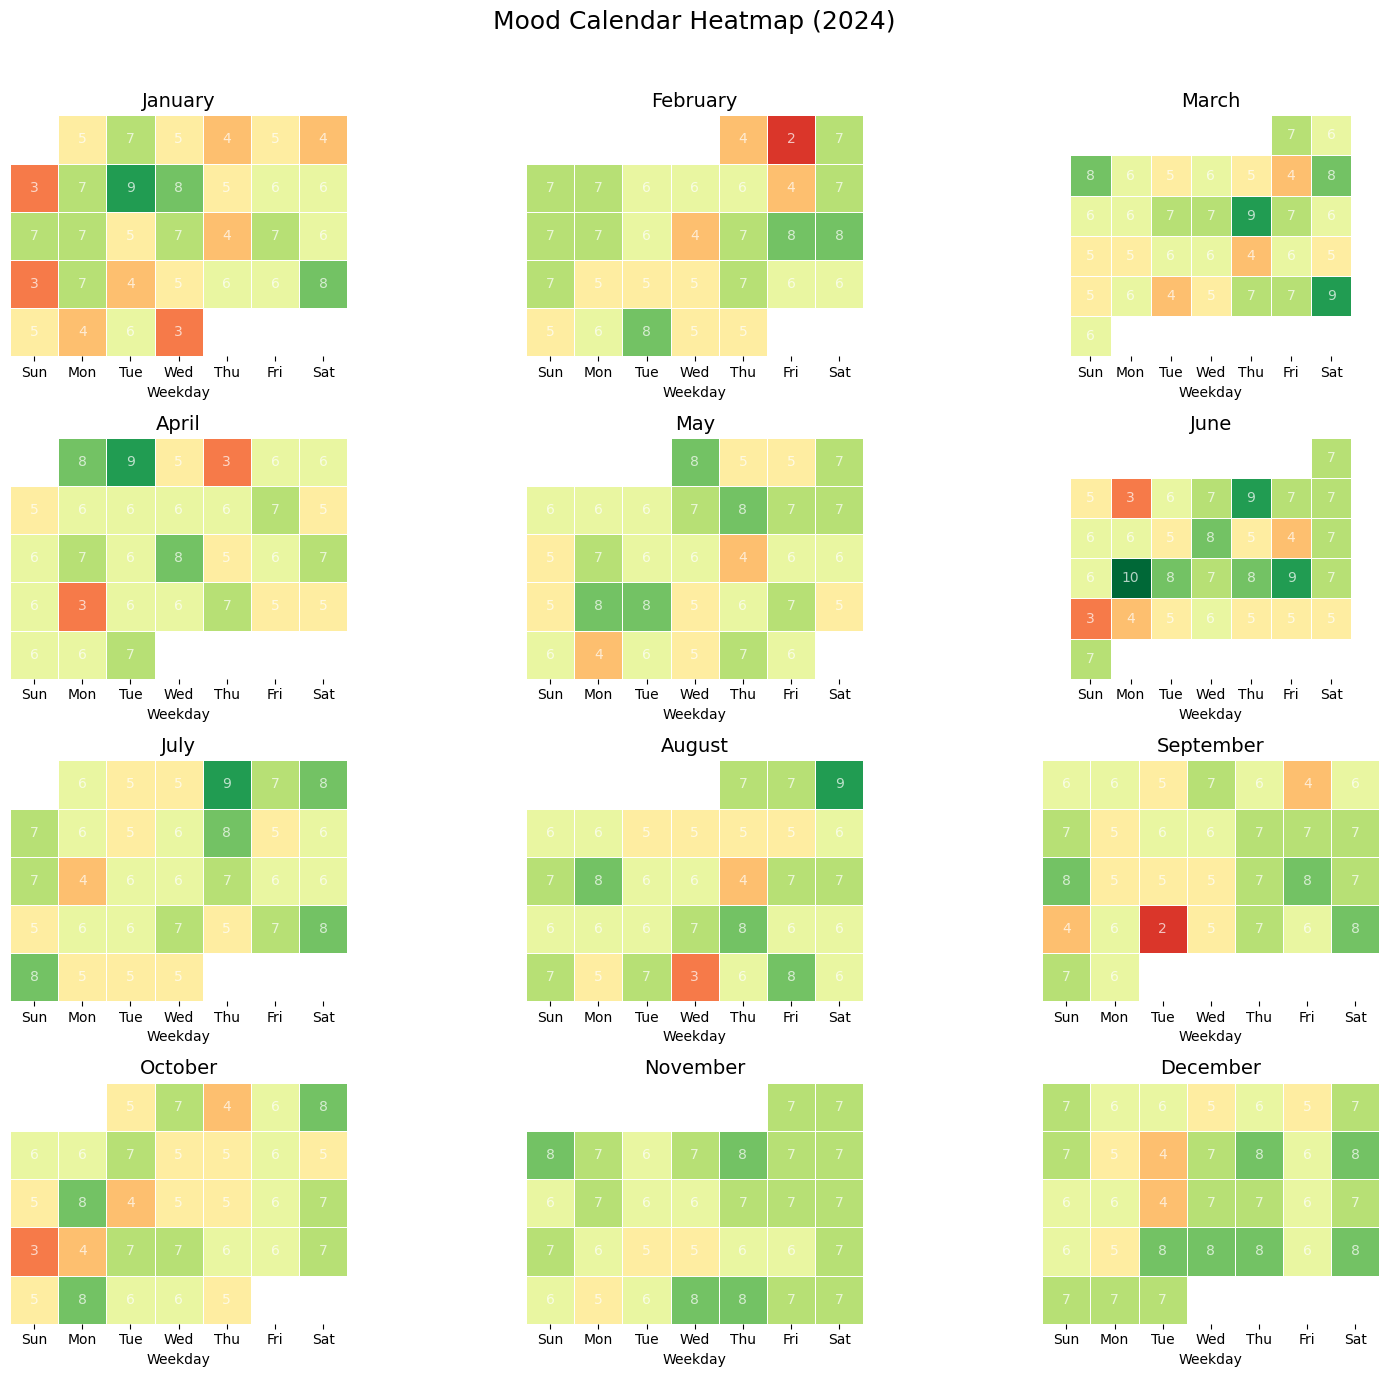

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import numpy as np

# Create the calendar heatmap
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 14))
fig.suptitle("Mood Calendar Heatmap (2024)", fontsize=18)

# Loop through months
for i, month in enumerate(calendar.month_name[1:], start=1):  # Skip empty month name
    ax = axes[(i-1)//3, (i-1)%3]
    month_data = life_tracker_df[life_tracker_df['Month'] == i]

    # Skip empty months
    if month_data.empty:
        ax.axis("off")
        continue

    # Generate pivot table
    pivot = month_data.pivot(index='WeekOfMonth', columns='Weekday', values='Mood')
    #display(pivot)

    # Plot heatmap
    sns.heatmap(
        pivot, 
        ax=ax, 
        cmap="RdYlGn", 
        cbar=False, 
        linewidths=0.5, 
        linecolor='white', 
        square=True, 
        vmin=1, 
        vmax=10
    )
    
    # Adjust axis labels and title
    ax.set_title(month, fontsize=14)
    ax.set_ylabel('')
    ax.set_xticks(np.arange(7) + 0.5)
    ax.set_xticklabels(["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], rotation=0)
    ax.set_yticks([])  # No labels for weeks of the month


    # Add numbers in the center of each square
    for y in range(pivot.shape[0]):
        for x in range(pivot.shape[1]):
            value = pivot.iloc[y, x]
            if not np.isnan(value):  # Only add numbers for valid entries
                ax.text(x + 0.5, y + 0.5, f"{int(value)}", 
                        ha='center', va='center', fontsize=10, 
                        color='white', alpha=0.7)  # Set opacity using alpha

# Adjust layout and show
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()